In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

In [2]:
display_quintiles = {
    1: "Poorest",
    2: "Second",
    3: "Third",
    4: "Fourth",
    5: "Wealthiest",
}

In [3]:
daly_categories = {
    "ntd": "NTD DALYs",
    "anemia": "Anemia DALYs",
    "lbwsg": "Child YLLs",
    "maternal_disorders": "Maternal disorders DALYs",
}

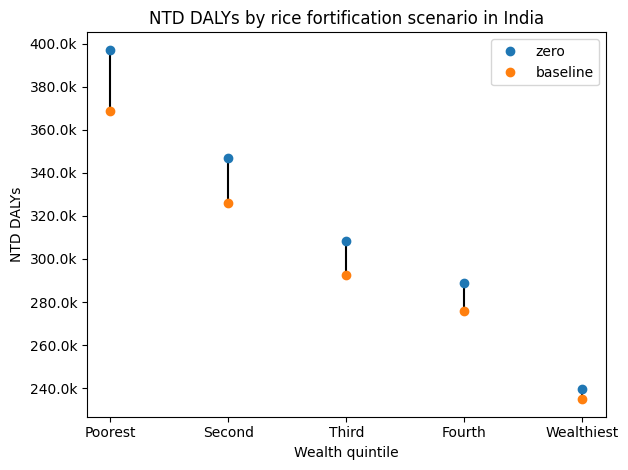

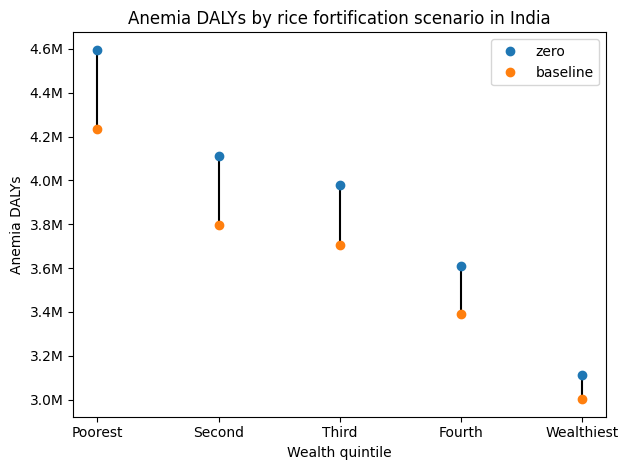

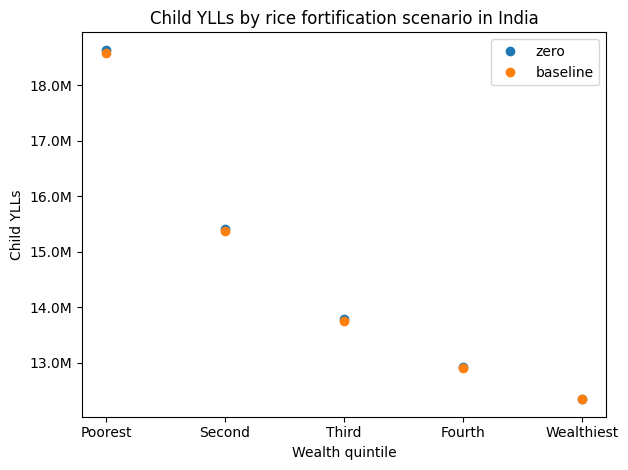

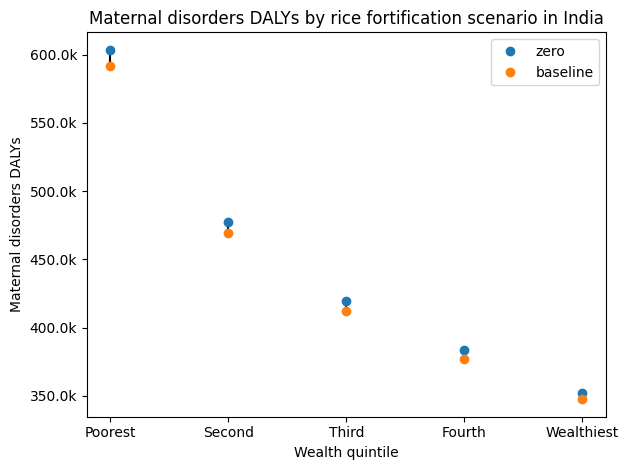

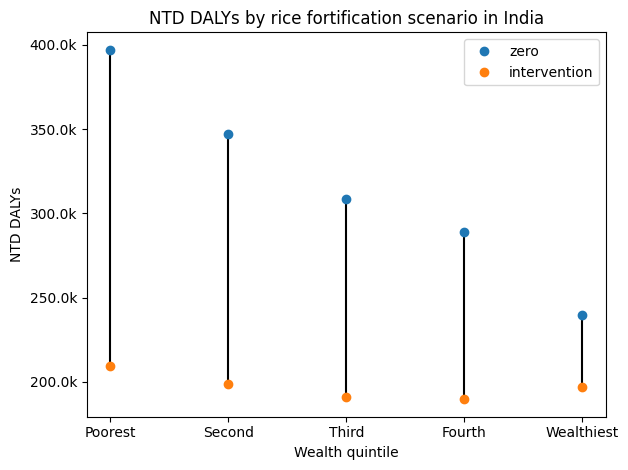

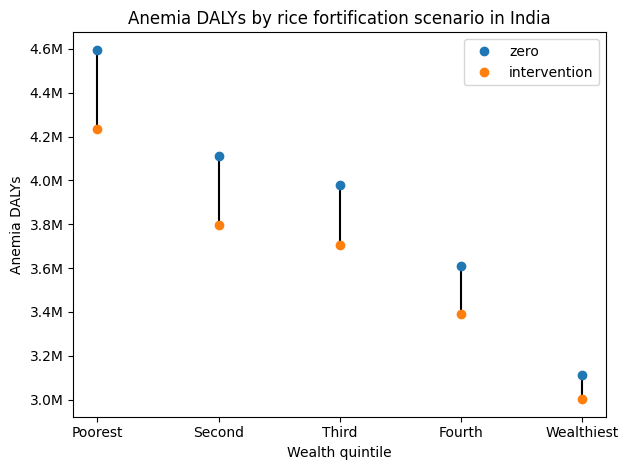

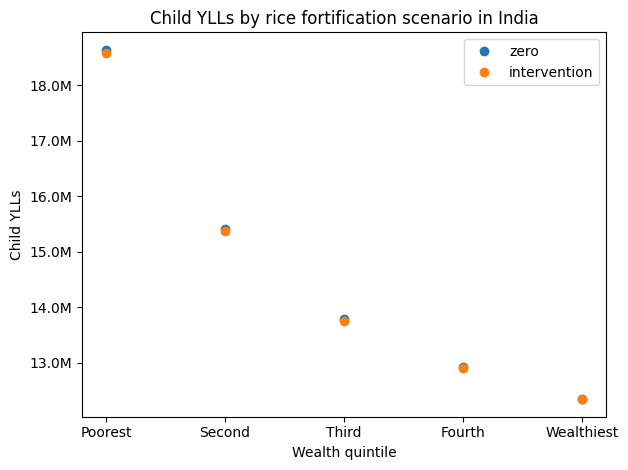

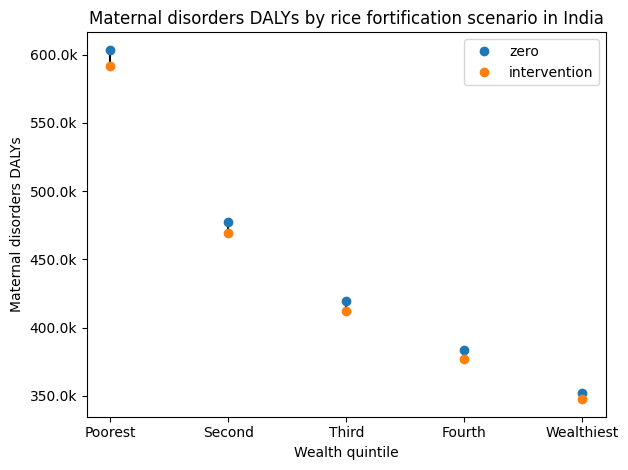

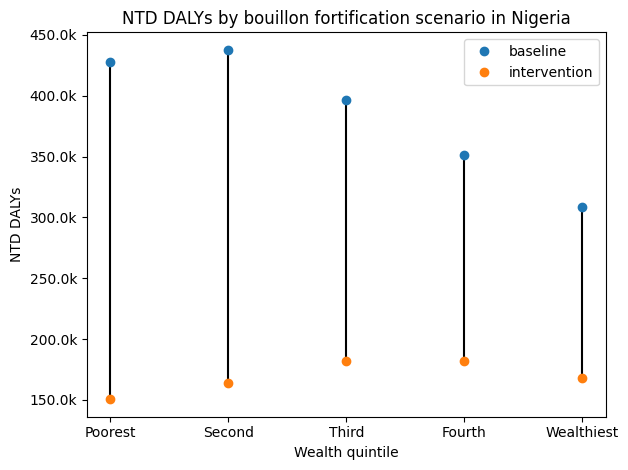

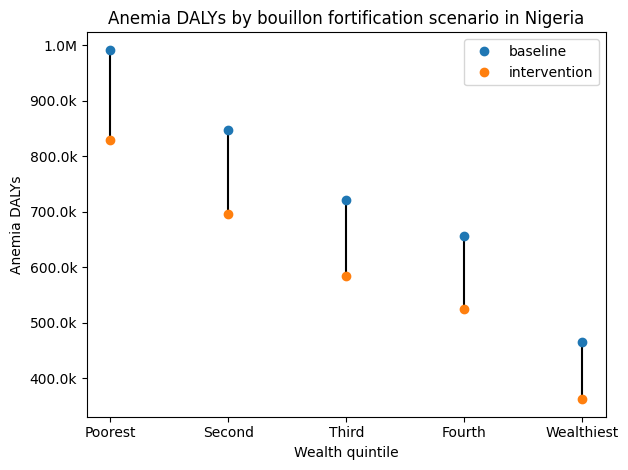

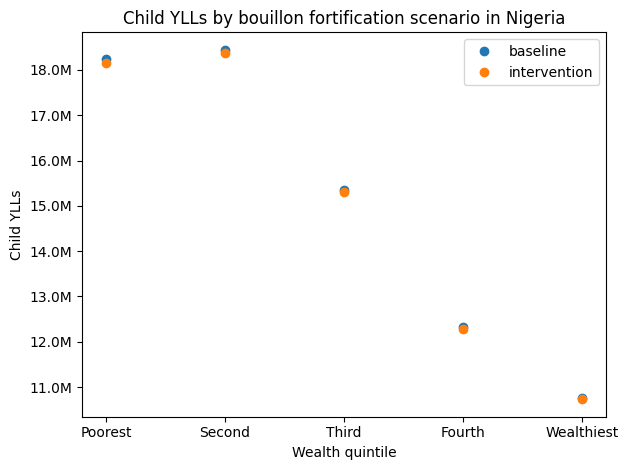

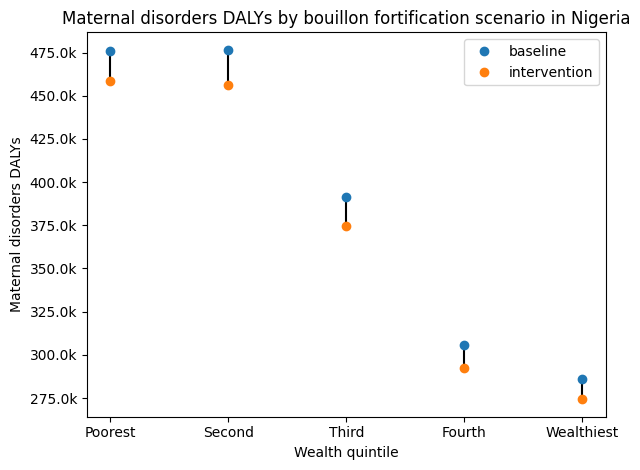

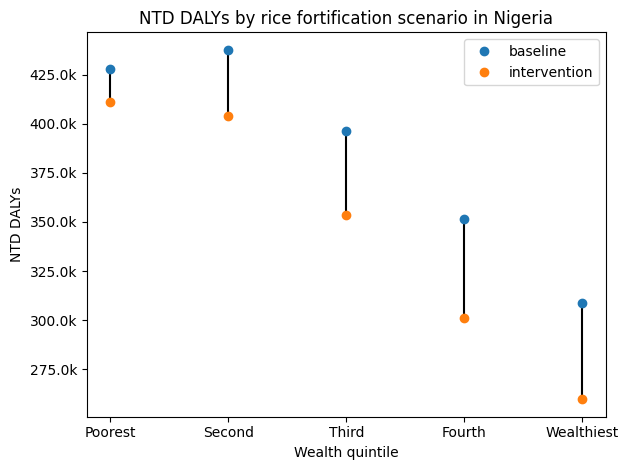

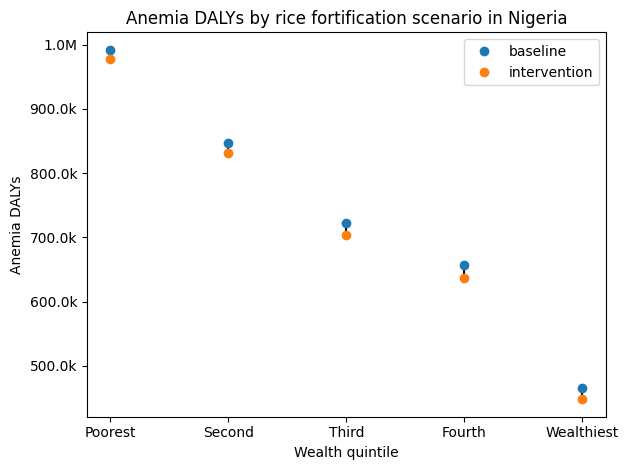

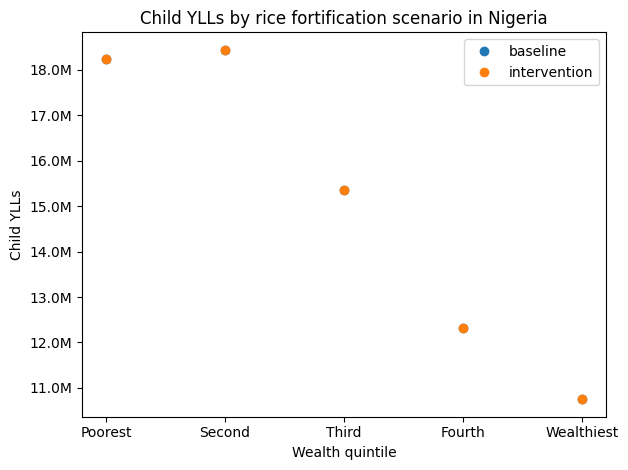

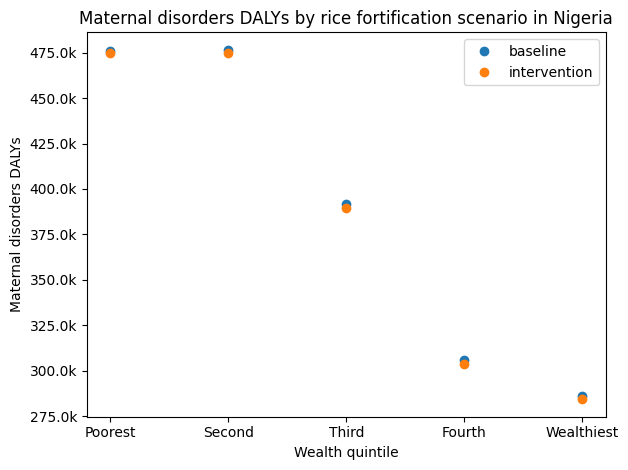

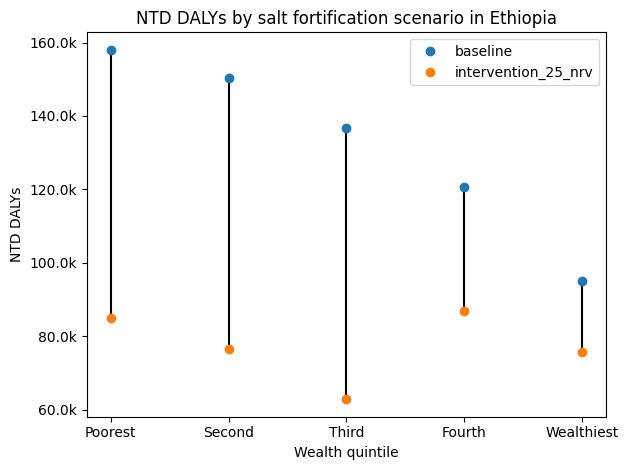

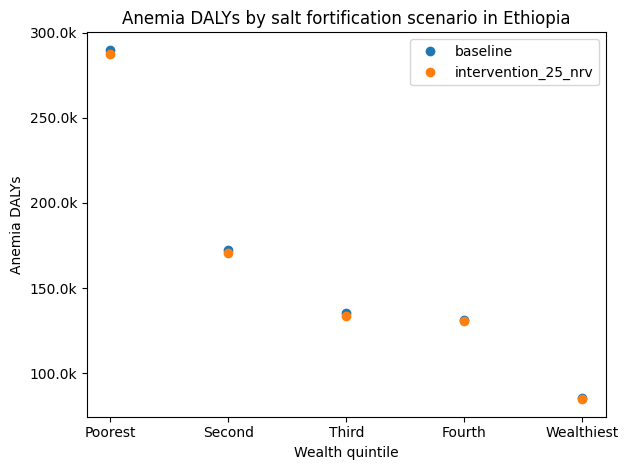

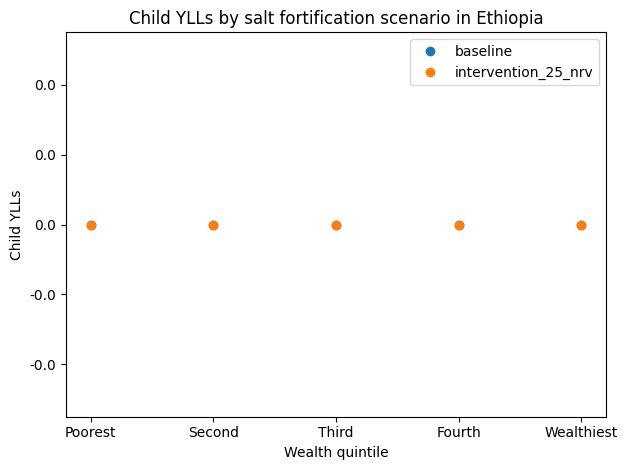

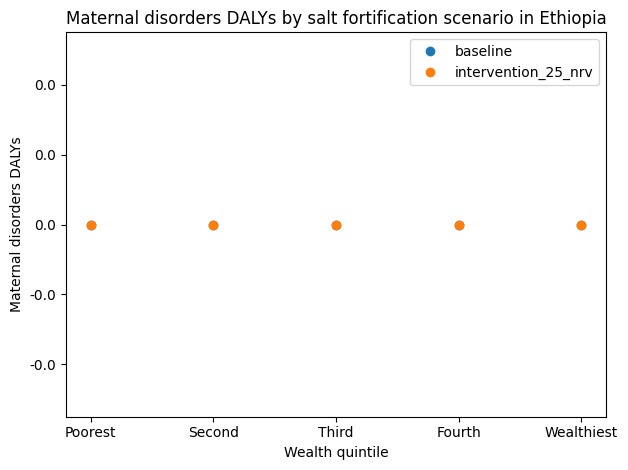

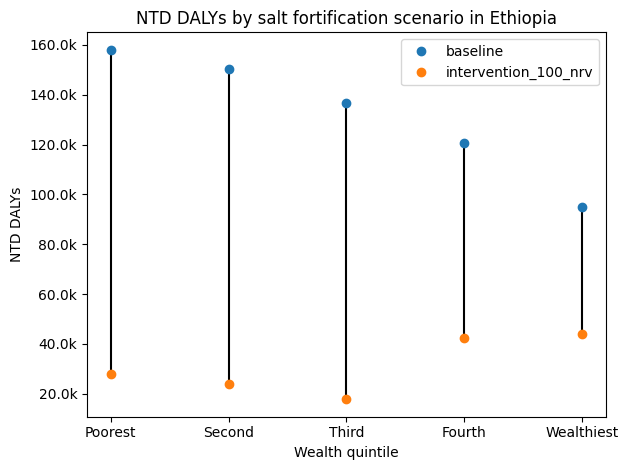

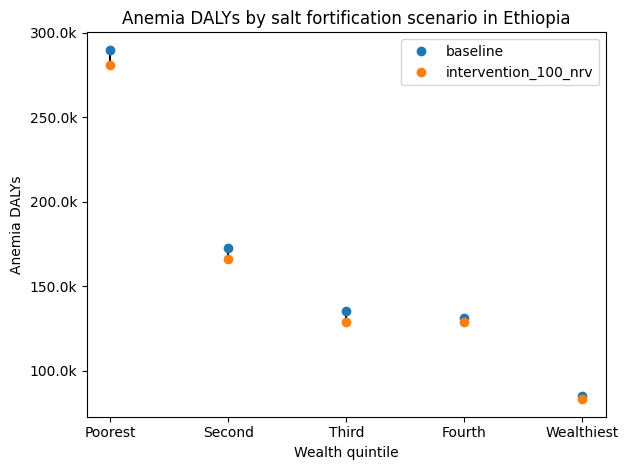

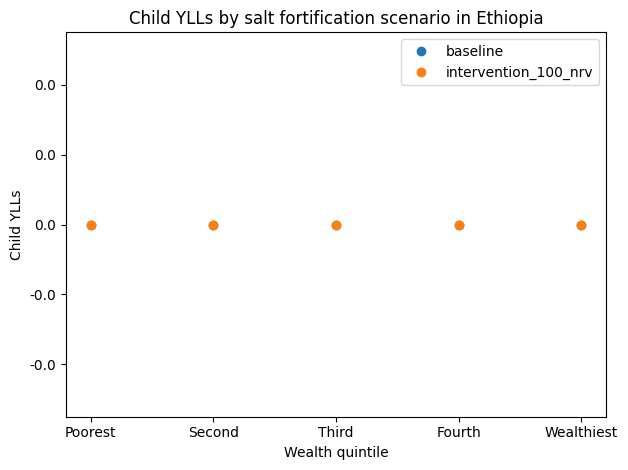

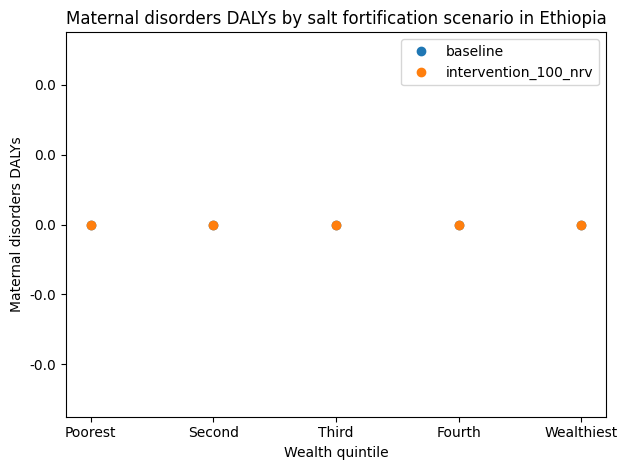

In [4]:
from matplotlib.ticker import FuncFormatter

# https://stackoverflow.com/a/61330823/
def human_format(num, pos):
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    # add more suffixes if you need them
    scale= ['', 'k', 'M', 'G', 'T', 'P'][magnitude]
    return f'{num:.1f}{scale}'

formatter = FuncFormatter(human_format)

for _, (
    location,
    vehicle,
    baseline_scenario,
    intervention_scenario,
    custom_name,
) in pd.read_csv("../0050_config/location_vehicle_scenario_comparisons.csv").iterrows():
    dalys_by_scenario = pd.read_csv(f"./results/{location}/{vehicle}/dalys_by_scenario.csv")

    for category, category_name in daly_categories.items():
        category_dalys_by_scenario = dalys_by_scenario.set_index(['entity', 'scenario', 'wealth_quintile']).loc[category]

        baseline_dalys = category_dalys_by_scenario.loc[baseline_scenario].reset_index()
        intervention_dalys = category_dalys_by_scenario.loc[intervention_scenario].reset_index()
        assert set(baseline_dalys.wealth_quintile.unique()) == set(intervention_dalys.wealth_quintile.unique())
        quintiles = display_quintiles.values()

        x = np.arange(len(quintiles))  # the label locations

        fig, ax = plt.subplots()

        ax.plot(
            np.array([[x[i], x[i], np.nan] for i in range(len(quintiles))]).flatten(),
            np.array([[baseline_dalys.set_index('wealth_quintile').value.loc[quintile], intervention_dalys.set_index('wealth_quintile').value.loc[quintile], np.nan] for quintile in display_quintiles.keys()]).flatten(),
            color='black',
        )

        ax.plot(x, baseline_dalys.set_index('wealth_quintile').value.loc[display_quintiles.keys()], label=baseline_scenario, linestyle='', marker='o')

        ax.plot(x, intervention_dalys.set_index('wealth_quintile').value.loc[display_quintiles.keys()], label=intervention_scenario, linestyle='', marker='o')

        ax.set_ylabel(category_name)
        ax.set_xlabel('Wealth quintile')
        ax.set_title(f'{category_name} by {vehicle} fortification scenario in {location.title()}')
        ax.set_xticks(x, quintiles)
        ax.legend(loc='upper right')
        ax.yaxis.set_major_formatter(formatter)

        plt.tight_layout()
        plt.show()